In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
(_,_), (images, labels) = mnist.load_data()

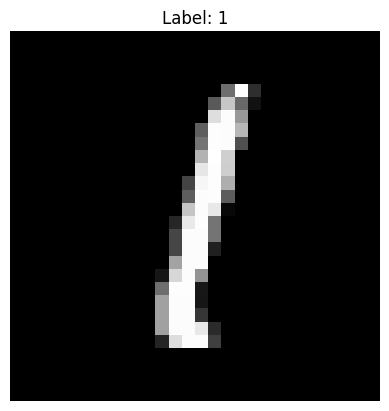

In [4]:
index = np.random.randint(0, images.shape[0])
image = images[index]
label = labels[index]

# Display it
plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [ ]:
def check_center(image):
    center_size = 8
    start = (image.shape[0] - center_size) // 2
    end = start + center_size
    center_square = image[start:end, start:end]           
    score = center_square.mean() / 255.0
    return score

def vertical_symmetry(image):
    flipped = np.fliplr(image)
    diff = np.abs(image - flipped)
    score = 1 - (diff.mean() / 255.0)
    return score

def horizontal_symmetry(image):
    flipped = np.flipud(image)
    diff = np.abs(image - flipped)
    score = 1 - (diff.mean() / 255.0)
    return score

def top_bottom_balance(image):
    mid = image.shape[0] // 2
    top = image[:mid, :].mean()
    bottom = image[mid:, :].mean()
    return (top - bottom) / 255.0

def pixel_density(image):
    return image.mean() / 255.0

def left_right_balance(image):
    mid = image.shape[1] // 2
    left = image[:, :mid].mean()
    right = image[:, mid:].mean()
    return (left - right) / 255.0

def active_pixels(image):
    return np.sum(image > 50) / (28 * 28)

features = [
    check_center(image),
    vertical_symmetry(image),
    horizontal_symmetry(image),
    top_bottom_balance(image),
    left_right_balance(image),
    pixel_density(image),
    active_pixels(image)
]

def classify(features):
    center, vertical_sym, horizontal_sym, tb, lr, density, active = features

    # 1 smal en weinig pixels
    if active < 0.15 and vertical_sym < 0.5:
        return 1

    # 0 symmetrisch en leeg midden
    if vertical_sym > 0.7 and center < 0.4 and active > 0.2:
        return 0

    # 8 symmetrisch + vol
    if vertical_sym > 0.8 and horizontal_sym > 0.8 and center > 0.5:
        return 8

    # 9 boven zwaar
    if tb > 0.1:
        return 9

    # 6 onder zwaar
    if tb < -0.1:
        return 6

    # 3 rechts zwaarder
    if lr < -0.05 and vertical_sym < 0.6:
        return 3

    # 2 weinig symmetrie, gemiddeld density
    if vertical_sym < 0.5 and horizontal_sym < 0.5:
        return 2

    # 7 boven zwaar + weinig symmetrie
    if tb > 0 and vertical_sym < 0.5:
        return 7

    # 5 fallback
    if density > 0.3:
        return 5

    return 4

def evaluate(images, labels, n_samples=10000):
    correct = 0
    
    indices = np.random.choice(len(images), n_samples, replace=False)

    for i in indices:
        image = images[i]
        true_label = labels[i]

        features = [
            check_center(image),
            vertical_symmetry(image),
            horizontal_symmetry(image),
            top_bottom_balance(image),
            left_right_balance(image),
            pixel_density(image),
            active_pixels(image)
        ]

        pred = classify(features)

        if pred == true_label:
            correct += 1

    accuracy = correct / n_samples
    print(f"Accuracy ({n_samples} samples): {accuracy * 100:.2f}%")

    return accuracy

evaluate(images, labels)

prediction = classify(features)
# print("Voorspeld cijfer:", prediction)


Accuracy (10000 samples): 16.31%
